In [155]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ====== 1) 时延距离标量 ======
def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    # 只取 galaxy lens 的宇宙学部分：R = Ds/Dls
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

def beta_scalar(zl: float, zs1: float, zs2: float, cosmo: Dict) -> float:
    """β_DSP(zl; zs1, zs2) = (D_ls2/D_s2) / (D_ls1/D_s1)."""
    return double_source_beta(float(zl), float(zs1), float(zs2), **cosmo)

def dlnR_dp(zl: float, zs: float, cosmo: dict, p: str,
            eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    base = R_scalar(zl, zs, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    # step choice
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # physical guards
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    c_m = cosmo.copy(); c_m[p] = p_minus
    c_p = cosmo.copy(); c_p[p] = p_plus
    Rm = R_scalar(zl, zs, c_m)
    Rp = R_scalar(zl, zs, c_p)
    if (Rm <= 0) or (Rp <= 0) or (not np.isfinite(Rm)) or (not np.isfinite(Rp)):
        return np.nan
    return float((np.log(Rp) - np.log(Rm)) / (p_plus - p_minus))

# ====== 2) 数值导数：∂ ln D_dt / ∂ p ======
def dlnDdt_dp(zl: float, zs: float, cosmo: Dict, p: str,
              eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    cosmo_p = cosmo.copy()
    base = Ddt_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    # 步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    # 中心差分
    cosmo_m = cosmo.copy();  cosmo_m[p]  = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Dm = Ddt_scalar(zl, zs, cosmo_m)
    Dp = Ddt_scalar(zl, zs, cosmo_p2)
    if (Dm <= 0) or (Dp <= 0) or (not np.isfinite(Dm)) or (not np.isfinite(Dp)):
        return np.nan

    return float((np.log(Dp) - np.log(Dm)) / (p_plus - p_minus))

def dlnbeta_dp(zl: float, zs1: float, zs2: float, cosmo: Dict, p: str,
               eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    对参数 p 求 ∂ ln β_DSP 的数值导数。
    - 对可能为 0/有号的参数（w0, wa, omega_k）用绝对步长；其余用相对步长。
    - 注意 β_DSP 与 H0 完全相消；若 p='H0'，导数应≈0（数值误差级）。
    """
    base = beta_scalar(zl, zs1, zs2, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        # p_minus = max(1e-6, p_minus); p_plus = max(1e-6, p_plus)
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    cosmo_m = cosmo.copy();  cosmo_m[p]  = p_minus
    cosmo_p = cosmo.copy();  cosmo_p[p]  = p_plus

    bm = beta_scalar(zl, zs1, zs2, cosmo_m)
    bp = beta_scalar(zl, zs1, zs2, cosmo_p)
    if (bm <= 0) or (bp <= 0) or (not np.isfinite(bm)) or (not np.isfinite(bp)):
        return np.nan

    return float((np.log(bp) - np.log(bm)) / (p_plus - p_minus))

# ====== helper：确保 H0 在参数列表里，并返回去重后的顺序表 ======
def _with_H0(params: List[str]) -> List[str]:
    seen = set()
    out = []
    for p in list(params) + ["H0"]:
        if p not in seen:
            out.append(p); seen.add(p)
    return out

# ====== 3) Fisher：单点 & 累积（始终把 H0 纳入）======
def fisher_single(zl: float, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    返回 (F, params_eff)：
      - F: (len(params_eff) x len(params_eff)) Fisher 矩阵
      - params_eff: 实际使用的参数顺序（原 params + 'H0'，去重）
    """
    params_eff = _with_H0(params)
    J = np.array([dlnDdt_dp(zl, zs, cosmo, p) for p in params_eff], dtype=float)  # ∂ln D_dt/∂p
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params_eff), len(params_eff))), params_eff
    F = np.outer(J, J) / (sigma_frac**2)
    return F, params_eff

def fisher_cumulative(zl_arr: np.ndarray, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    把一个 z_s 下所有 z_l 的 Fisher 相加。
    返回 (F, params_eff)。
    """
    params_eff = _with_H0(params)
    F = np.zeros((len(params_eff), len(params_eff)), dtype=float)
    for zl in zl_arr:
        if zl <= 0 or zl >= zs:
            continue
        F_k, _ = fisher_single(float(zl), float(zs), cosmo, params_eff, sigma_frac)
        F += F_k
    return F, params_eff

# ====== 4) zl 网格 ======
def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)



In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_sensitivity_3x4(
    zs_list, zl_list, zs2_fixed, cosmo_cpl, *,
    sigma_frac=0.05, dz=0.004, npts_zs1=400, eps=1e-6,
    sharey_by_row=False, figsize=(16, 11), outputname="fisher_all_3x4.png"
):
    """
    3x4 panels:
      Row 1: R = Ds/Dls sensitivities vs z_l (curves: different z_s)
      Row 2: D_dt sensitivities vs z_l (curves: different z_s)
      Row 3: beta_DSP sensitivities vs z_s1 (curves: different z_l; z_s2 fixed)

    Y-limits are set *independently* for each subplot.
    """
    # Force CPL branch (remove 'w')
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params     = ["omega_m", "omega_k", "w0", "wa"]
    col_titles = [r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"]

    # Never share y; we want independent limits for every subplot
    fig, axes = plt.subplots(3, 4, figsize=figsize, sharex=False, sharey=False)
    axes = np.asarray(axes)

    # ---------- Row 1: R ----------
    for j, (p, ttl) in enumerate(zip(params, col_titles)):
        ax = axes[0, j]
        for zs in zs_list:
            zls = zl_grid_for_zs(zs, dz=dz)
            sens = []
            for zl in zls:
                d = dlnR_dp(zl, zs, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            m = np.isfinite(zls) & np.isfinite(sens)
            if np.any(m):
                ax.plot(zls[m], np.asarray(sens)[m], lw=1.6, label=fr"$z_s={zs:.1f}$")
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl,fontsize=15)
        if j == 0:
            # ax.set_ylabel(r"$R$: $|\partial \ln (D_s/D_{ls})/\partial p| \,/\, \sigma_{\ln R}$")
            ax.set_ylabel(r"$\mathcal{R}_{DR}$")
        ax.set_xlabel(r"$z_l$", fontsize=15)

        # independent y-lims
        if p == "omega_m":
            ax.set_ylim(bottom=1.0)
        elif p == "omega_k":
            ax.set_ylim(bottom=1.0)
        elif p == "w0":
            ax.set_ylim(bottom=1e-3)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    # ---------- Row 2: D_dt ----------
    for j, (p, ttl) in enumerate(zip(params, col_titles)):
        ax = axes[1, j]
        for zs in zs_list:
            zls = zl_grid_for_zs(zs, dz=dz)
            sens = []
            for zl in zls:
                d = dlnDdt_dp(zl, zs, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            m = np.isfinite(zls) & np.isfinite(sens)
            if np.any(m):
                ax.plot(zls[m], np.asarray(sens)[m], lw=1.6, label=fr"$z_s={zs:.1f}$")
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(r"$D_{\Delta t}$: $|\partial \ln D_{\Delta t}/\partial p| \,/\, \sigma_{\ln D}$")
            ax.set_ylabel(r"$\mathcal{R}_{\Delta t}$")
        ax.set_xlabel(r"$z_l$", fontsize=15)

        # independent y-lims
        if p == "omega_m":
            ax.set_ylim(bottom=1e-3)
        elif p == "omega_k":
            ax.set_ylim(bottom=1e-2)
        elif p == "w0":
            ax.set_ylim(bottom=1e-1)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    # ---------- Row 3: beta_DSP (vs z_s1) ----------
    for j, (p, ttl) in enumerate(zip(params, col_titles)):
        ax = axes[2, j]
        for zl in zl_list:
            if not (zl + eps < zs2_fixed - eps):
                continue
            z1_lo = zl + eps
            z1_hi = zs2_fixed - eps
            n_this = max(8, int(npts_zs1 * (z1_hi - z1_lo) / max(zs2_fixed, 1e-8)))
            z1_grid = np.linspace(z1_lo, z1_hi, n_this)

            sens = []
            for zs1 in z1_grid:
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
            m = np.isfinite(z1_grid) & np.isfinite(sens)
            if np.any(m):
                ax.plot(z1_grid[m], np.asarray(sens)[m], lw=1.6, ls='--', label=fr"$z_l={zl:.2f}$")
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        if j == 0:
            # ax.set_ylabel(r"$\beta_{\rm DSP}$: $|\partial \ln \beta/\partial p| \,/\, \sigma_{\ln \beta}$")
            ax.set_ylabel(r"$\mathcal{R}_{DSPDR}$")
        ax.set_xlabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.1f}$)", fontsize=15)

        # independent y-lims
        if p == "omega_m":
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(bottom=0.01, top=max(ymax, 0.5))
        elif p == "omega_k":
            ax.set_ylim(bottom=1e-3)
        elif p == "w0":
            ax.set_ylim(bottom=1e-3)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    # --------- single bottom legend ----------
    handles1, labels1 = axes[0,0].get_legend_handles_labels()  # z_s legend
    handles3, labels3 = axes[2,0].get_legend_handles_labels()  # z_l legend
    handles = handles1 + handles3
    labels  = labels1  + labels3
    if handles:
        fig = axes[0,0].figure
        fig.legend(handles, labels, loc="lower center",
                   ncol=min(len(labels), 6), frameon=False, fontsize=15)

    plt.tight_layout(rect=[0.03, 0.10, 0.98, 0.94])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


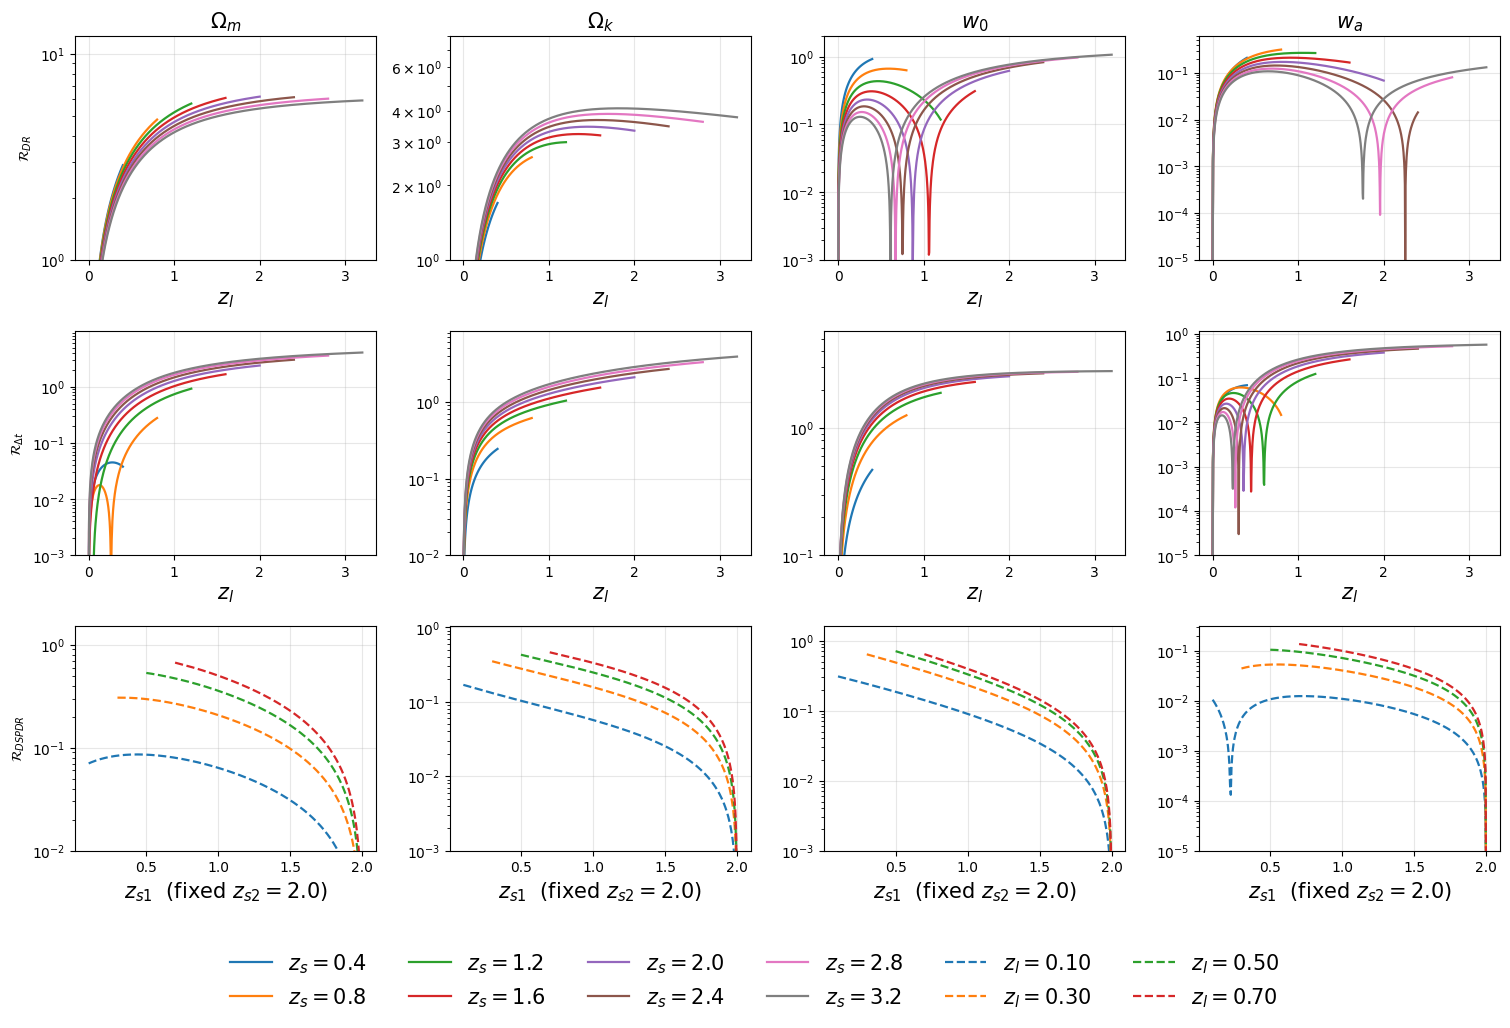

In [27]:
cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
zs_list    = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
zl_list    = [0.10, 0.30, 0.50, 0.70]
zs2_fixed  = 2.0

plot_all_sensitivity_3x4(
    zs_list, zl_list, zs2_fixed, cosmo_cpl,
    sigma_frac=0.1, dz=0.004, npts_zs1=400, sharey_by_row=False,
    outputname="fisher_all_3x4.png"
)


In [149]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext 


def plot_sensitivity_contours_3x4(
    cosmo_cpl,
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    zs2_fixed=2.0, zs1_step=0.1, eps=1e-6,
    # sensitivity
    sigma_frac=0.1,
    # styling (colormap still customizable)
    cmap="viridis",
    # figure
    figsize=(16, 11),
    outputname="contours_all_3x4.png"
):
    """
    3 rows × 4 columns of 2D sensitivity contours with ONE shared colorbar (right side).
    Shared color scale: 16 log-spaced levels from 1e-4 to 1e1.
    Requires dlnR_dp, dlnDdt_dp, dlnbeta_dp in scope.
    """
    # ---- ensure CPL keys (no 'w') ----
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params    = ["omega_m", "omega_k", "w0", "wa"]
    param_tex1 = [r"$\mathcal{R}_{DR}-\Omega_m$", r"$\mathcal{R}_{DR}-\Omega_k$", 
                  r"$\mathcal{R}_{DR}-w_0$", r"$\mathcal{R}_{DR}-w_a$"]
    param_tex2 = [r"$\mathcal{R}_{\Delta t}-\Omega_m$", r"$\mathcal{R}_{\Delta t}-\Omega_k$", 
                  r"$\mathcal{R}_{\Delta t}-w_0$", r"$\mathcal{R}_{\Delta t}-w_a$"]
    param_tex3 = [r"$\mathcal{R}_{DSPDR}-\Omega_m$", r"$\mathcal{R}_{DSPDR}-\Omega_k$", 
                  r"$\mathcal{R}_{DSPDR}-w_0$", r"$\mathcal{R}_{DSPDR}-w_a$"]

    # ---- grids ----
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, zs2_fixed + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # ---- sensitivity helpers ----
    def _grid_S(deriv_fn, param):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # zs index
            for j in range(ZL.shape[1]):  # zl index
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = deriv_fn(zl, zs, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    def _grid_S_beta(param):
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):     # zs1 index
            for j in range(ZL_b.shape[1]): # zl index
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # ---- shared color scale (16 levels, 1e-4 to 1e1) ----
    vmin, vmax = 1e-4, 1e1
    levels01 = np.logspace(-4, 0, 16)
    levels02 = np.linspace(1,10,13)[1:]
    levels = np.r_[levels01,levels02]
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # ---- figure (leave room on right for shared colorbar) ----
    fig, axes = plt.subplots(3, 4, figsize=figsize, sharex=False, sharey=False)
    axes = np.asarray(axes)
    fig.subplots_adjust(right=0.86)  # free right margin for colorbar

    # in-panel parameter label style
    txt_kw = dict(ha="right", va="bottom", fontsize=20,)

    # -------- Row 1: R --------
    for j, (p, ptex) in enumerate(zip(params, param_tex1)):
        ax = axes[0, j]
        S = _grid_S(dlnR_dp, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        # optional line contours
        # ax.contour(zl_grid, zs_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(r"$z_s$",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # -------- Row 2: D_dt --------
    for j, (p, ptex) in enumerate(zip(params, param_tex2)):
        ax = axes[1, j]
        S = _grid_S(dlnDdt_dp, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        # ax.contour(zl_grid, zs_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(r"$z_s$",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # -------- Row 3: beta_DSP (vs z_s1) --------
    for j, (p, ptex) in enumerate(zip(params, param_tex3)):
        ax = axes[2, j]
        S = _grid_S_beta(p)
        cf = ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
        # ax.contour(zl_grid, zs1_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.1f}$)",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # ---- shared colorbar on the right ----
    # Add a dedicated axes for the cbar; share across all subplots
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    # cb.set_label(r"Sensitivity: $|\partial \ln \mathcal{R}/\partial p|\,/\,\sigma_{\ln \mathcal{R}}$")

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])  # leave space for cbar
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1850148/2495295628.py:117: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
/tmp/ipykernel_1850148/2495295628.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])  # leave space for cbar


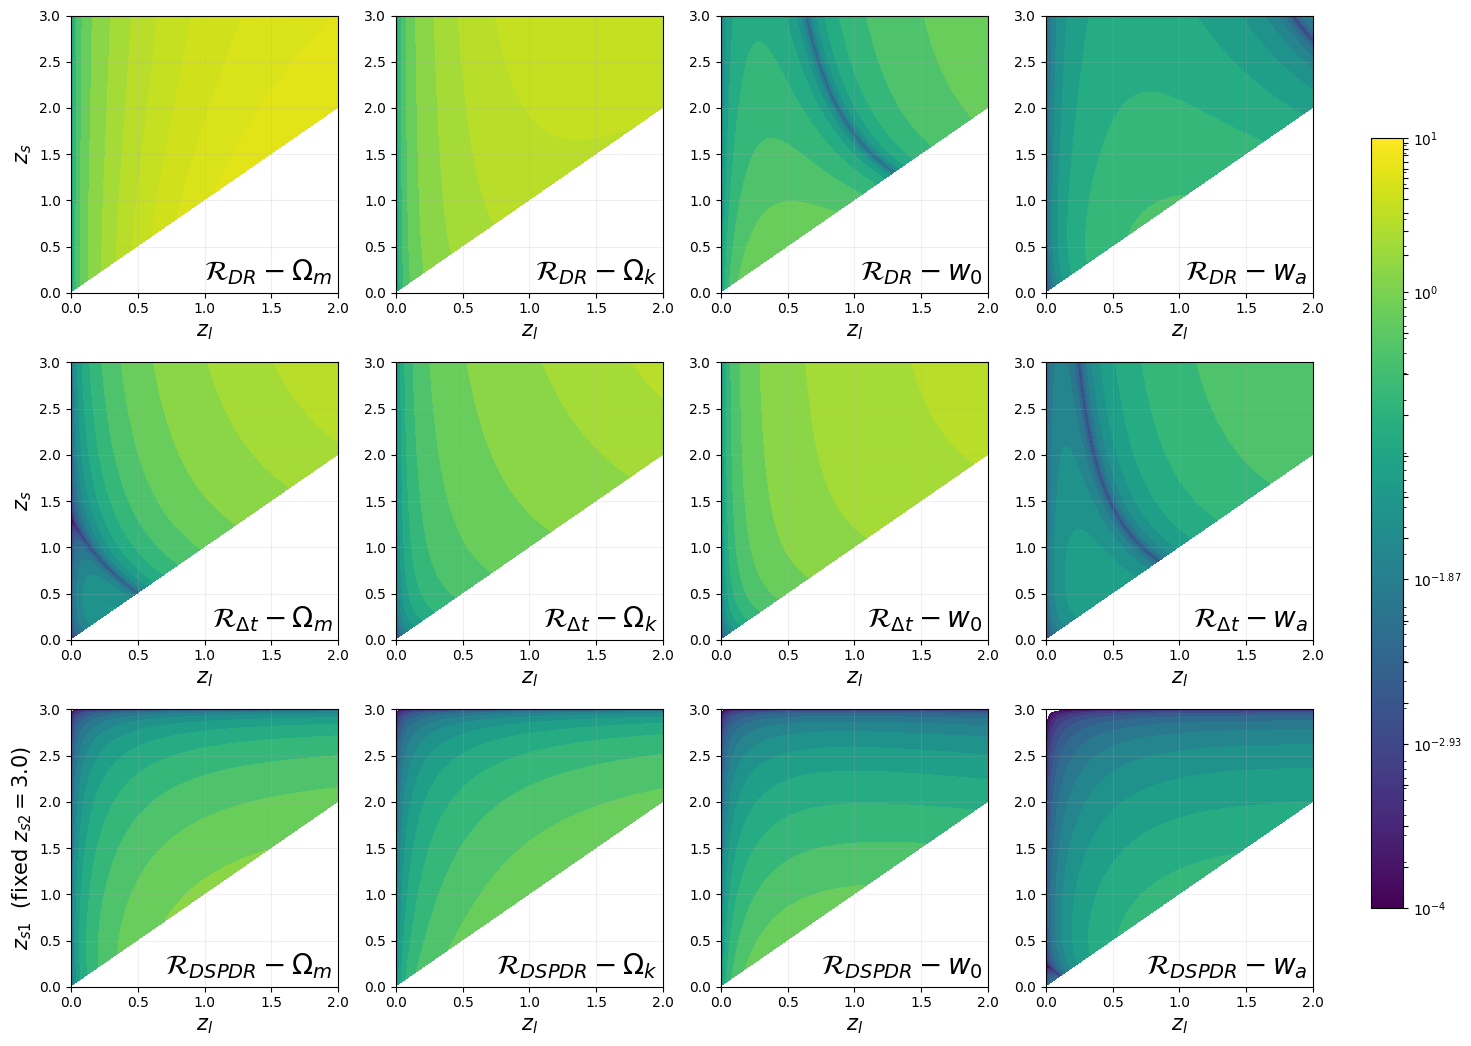

In [150]:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# Optional: customize per-subplot lower limits (vmin) if desired
vmins = {
    "R":   {"omega_m": 1.5,  "omega_k": 1.5,  "w0": 1e-3, "wa": 1e-5},
    "Ddt": {"omega_m": 1e-3,  "omega_k": 0.1,  "w0": 0.1, "wa": 1e-5},
    "beta":{"omega_m": 0.02, "omega_k": 1e-3, "w0": 1e-3, "wa": 1e-5},  # example tweak
}

plot_sensitivity_contours_3x4(
    cosmo_cpl,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    zs2_fixed=3., zs1_step=0.01,
    sigma_frac=0.1,
    outputname="contours_all_3x4.png"
)


In [168]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext 


def plot_sensitivity_contours_3x4(
    cosmo_cpl,
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    zs2_fixed=2.0, zs1_step=0.1, eps=1e-6,
    # sensitivity
    sigma_frac=0.1,
    # styling (colormap still customizable)
    cmap="viridis",
    # figure
    figsize=(16, 11),
    outputname="contours_all_3x4.png"
):
    """
    3 rows × 4 columns of 2D sensitivity contours with ONE shared colorbar (right side).
    Shared color scale: 16 log-spaced levels from 1e-4 to 1e1.
    Requires dlnR_dp, dlnDdt_dp, dlnbeta_dp in scope.
    """
    # ---- ensure CPL keys (no 'w') ----
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params    = ["omega_m", "omega_k", "w0", "wa"]
    param_tex1 = [r"$\mathcal{R}_{DR}-\Omega_m$", r"$\mathcal{R}_{DR}-\Omega_k$", 
                  r"$\mathcal{R}_{DR}-w_0$", r"$\mathcal{R}_{DR}-w_a$"]
    param_tex2 = [r"$\mathcal{R}_{\Delta t}-\Omega_m$", r"$\mathcal{R}_{\Delta t}-\Omega_k$", 
                  r"$\mathcal{R}_{\Delta t}-w_0$", r"$\mathcal{R}_{\Delta t}-w_a$"]
    param_tex3 = [r"$\mathcal{R}_{DSPDR}-\Omega_m$", r"$\mathcal{R}_{DSPDR}-\Omega_k$", 
                  r"$\mathcal{R}_{DSPDR}-w_0$", r"$\mathcal{R}_{DSPDR}-w_a$"]

    # ---- grids ----
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, zs2_fixed + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # ---- sensitivity helpers ----
    def add_white_arrows(ax, specs, *, use_axes_coords=False):
        """
        specs: list of dict, each dict example:
          dict(xy=(x1,y1), xytext=(x0,y0), label="A", lpos=0.5, offset=(0.02,0.02))
        - xy/xytext: arrow end/start
        - label: optional letter
        - lpos: label position along the arrow (0=start, 1=end)
        - offset: label offset (in same coord system)
        - use_axes_coords: True -> coords in ax.transAxes (0-1); False -> data coords
        """
        xycoords = "axes fraction" if use_axes_coords else "data"
    
        # 实心白箭头：用 arrowstyle="simple" 比 "-|>" 更像你图2那种“白色块状箭头”
        arrowprops = dict(
            arrowstyle="simple,head_length=1.0,head_width=1.0,tail_width=0.25",
            fc="white", ec="white", lw=0.0,  # 填充白色，无边框
            mutation_scale=18,               # 总体大小（可调大/小）
            shrinkA=0, shrinkB=0
        )
    
        for s in specs:
            x0, y0 = s["xytext"]  # start
            x1, y1 = s["xy"]      # end
    
            # 只画箭头本体（不写文字）
            ax.annotate(
                "", xy=(x1, y1), xytext=(x0, y0),
                xycoords=xycoords, textcoords=xycoords,
                arrowprops=arrowprops,
                zorder=50  # 保证压在 contourf 上面
            )
    
            # 可选：在箭头旁边加字母
            lab = s.get("label", None)
            if lab:
                t = float(s.get("lpos", 0.5))
                dx, dy = s.get("offset", (0.02, 0.02))
    
                tx = x0 + t * (x1 - x0) + dx
                ty = y0 + t * (y1 - y0) + dy
    
                ax.text(
                    tx, ty, lab,
                    color="white", fontsize=16, fontweight="bold",
                    ha="center", va="center",
                    zorder=60
                )

    
    def _grid_S(deriv_fn, param):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # zs index
            for j in range(ZL.shape[1]):  # zl index
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = deriv_fn(zl, zs, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    def _grid_S_beta(param):
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):     # zs1 index
            for j in range(ZL_b.shape[1]): # zl index
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # ---- shared color scale (16 levels, 1e-4 to 1e1) ----
    vmin, vmax = 1e-4, 1e1
    levels01 = np.logspace(-4, 0, 16)
    levels02 = np.linspace(1,10,13)[1:]
    levels = np.r_[levels01,levels02]
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # ---- figure (leave room on right for shared colorbar) ----
    fig, axes = plt.subplots(3, 4, figsize=figsize, sharex=False, sharey=False)
    axes = np.asarray(axes)
    fig.subplots_adjust(right=0.86)  # free right margin for colorbar

    # in-panel parameter label style
    txt_kw = dict(ha="right", va="bottom", fontsize=20,)

    # -------- Row 1: R --------
    for j, (p, ptex) in enumerate(zip(params, param_tex1)):
        ax = axes[0, j]
        S = _grid_S(dlnR_dp, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        # optional line contours
        # ax.contour(zl_grid, zs_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(r"$z_s$",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

        # arrows
        specs = arrow_map.get((0, j), None)
        if specs:
            add_white_arrows(ax, specs, use_axes_coords=True)

    # -------- Row 2: D_dt --------
    for j, (p, ptex) in enumerate(zip(params, param_tex2)):
        ax = axes[1, j]
        S = _grid_S(dlnDdt_dp, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        # ax.contour(zl_grid, zs_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(r"$z_s$",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

        # arrows
        specs = arrow_map.get((1, j), None)
        if specs:
            add_white_arrows(ax, specs, use_axes_coords=True)

    # -------- Row 3: beta_DSP (vs z_s1) --------
    for j, (p, ptex) in enumerate(zip(params, param_tex3)):
        ax = axes[2, j]
        S = _grid_S_beta(p)
        cf = ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
        # ax.contour(zl_grid, zs1_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        if j == 0:
            ax.set_ylabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.1f}$)",fontsize=15)
        ax.set_xlabel(r"$z_l$",fontsize=15)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

        # arrows
        specs = arrow_map.get((2, j), None)
        if specs:
            add_white_arrows(ax, specs, use_axes_coords=True)
            
    # ---- shared colorbar on the right ----
    # Add a dedicated axes for the cbar; share across all subplots
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    # cb.set_label(r"Sensitivity: $|\partial \ln \mathcal{R}/\partial p|\,/\,\sigma_{\ln \mathcal{R}}$")

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])  # leave space for cbar
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1850148/2473912042.py:176: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
/tmp/ipykernel_1850148/2473912042.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])  # leave space for cbar


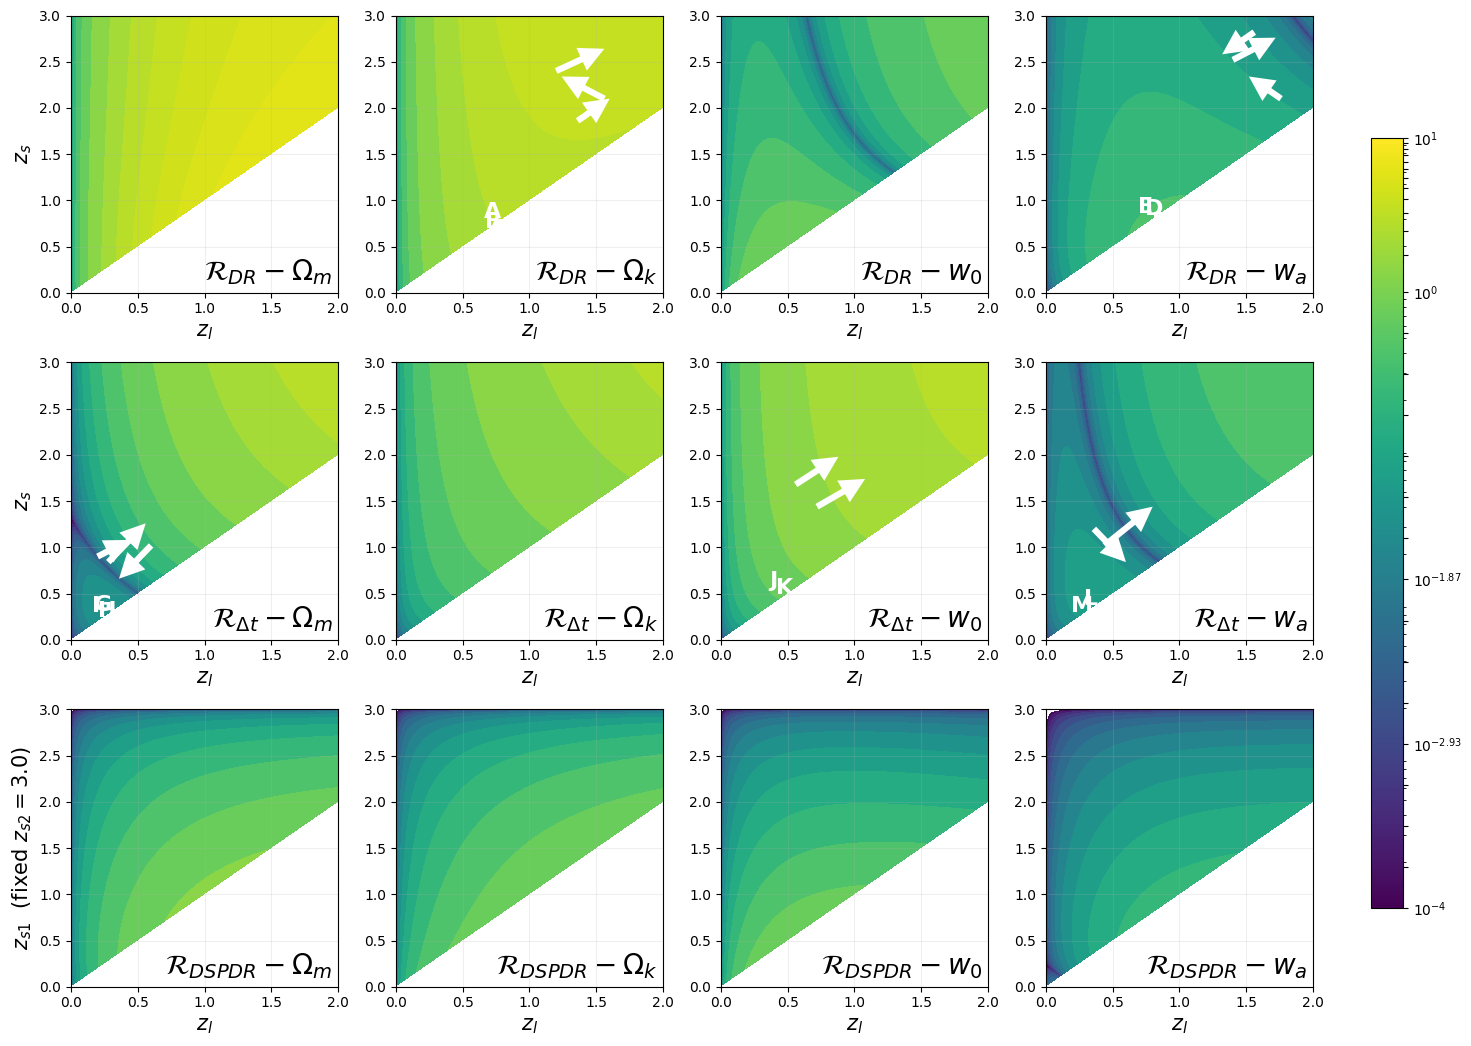

In [169]:
# 以 (row, col) 索引子图：row=0..2, col=0..3
arrow_map = {
    (0, 1): [  # 第一行第二列
        dict(xy=(0.78, 0.88), xytext=(0.60, 0.80), label="A", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.62, 0.78), xytext=(0.78, 0.70), label="B", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.80, 0.70), xytext=(0.68, 0.62), label="C", lpos=0.5, offset=(0.03, 0.03)),
    ],
    (0, 3): [  # 第一行第四列
        dict(xy=(0.86, 0.92), xytext=(0.70, 0.84), label="D", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.66, 0.86), xytext=(0.78, 0.94), label="E", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.76, 0.78), xytext=(0.88, 0.70), label="F", lpos=0.5, offset=(0.03, 0.03)),
    ],
    (1, 0): [  # 第二行第一列
        dict(xy=(0.28, 0.42), xytext=(0.14, 0.28), label="G", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.18, 0.22), xytext=(0.30, 0.34), label="H", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.22, 0.36), xytext=(0.10, 0.30), label="I", lpos=0.5, offset=(0.03, 0.03)),
    ],
    (1, 2): [  # 第二行第三列
        dict(xy=(0.44, 0.66), xytext=(0.28, 0.56), label="J", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.54, 0.58), xytext=(0.36, 0.48), label="K", lpos=0.5, offset=(0.03, 0.03)),
    ],
    (1, 3): [  # 第二行第四列
        dict(xy=(0.40, 0.48), xytext=(0.22, 0.34), label="L", lpos=0.5, offset=(0.03, 0.03)),
        dict(xy=(0.30, 0.28), xytext=(0.18, 0.40), label="M", lpos=0.5, offset=(0.03, 0.03)),
    ],
}


cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# Optional: customize per-subplot lower limits (vmin) if desired
vmins = {
    "R":   {"omega_m": 1.5,  "omega_k": 1.5,  "w0": 1e-3, "wa": 1e-5},
    "Ddt": {"omega_m": 1e-3,  "omega_k": 0.1,  "w0": 0.1, "wa": 1e-5},
    "beta":{"omega_m": 0.02, "omega_k": 1e-3, "w0": 1e-3, "wa": 1e-5},  # example tweak
}

plot_sensitivity_contours_3x4(
    cosmo_cpl,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    zs2_fixed=3., zs1_step=0.01,
    sigma_frac=0.1,
    outputname="contours_all_3x4_arrow01.png"
)


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext  # <- correct module

def plot_sensitivity_contours_1x2(
    cosmo_cpl,
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    # sensitivity
    sigma_frac=0.1,
    # styling
    cmap="viridis",
    # figure
    figsize=(10, 4.2),
    outputname="contours_R_w0_wa.png"
):
    """
    Make ONLY 2 subplots for the first row (R=Ds/Dls): parameters w0 and wa.
    Each panel shows sensitivity S = |∂ ln R / ∂ p| / σ_lnR in (z_l, z_s).
    One shared colorbar on the right with 16 log-spaced levels from 1e-4 to 1e1.

    Requires dlnR_dp in scope.
    """

    # ---- ensure CPL keys (no 'w') ----
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    # We only plot the third & fourth parameters for R:
    params    = ["w0", "wa"]
    param_tex = [r"$\mathcal{R}_{\rm DR}-w_0$", r"$\mathcal{R}_{\rm DR}-w_a$"]

    # ---- grids ----
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    # ---- sensitivity helper for R ----
    def _grid_S_R(param):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # over z_s
            for j in range(ZL.shape[1]):  # over z_l
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = dlnR_dp(zl, zs, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # ---- shared color scale (16 levels, 1e-4 to 1e1) ----
    vmin, vmax = 1e-4, 1e1
    levels = np.logspace(-4, 1, 16)
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # ---- figure (leave room on right for shared colorbar) ----
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)
    axes = np.atleast_1d(axes)
    fig.subplots_adjust(right=0.86)  # free right margin for colorbar

    # in-panel parameter label style
    txt_kw = dict(ha="right", va="bottom", fontsize=14)

    # -------- Row 1 (R): only w0 and wa --------
    for ax, p, ptex in zip(axes, params, param_tex):
        S = _grid_S_R(p)
        ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        # Optional line contours:
        # ax.contour(zl_grid, zs_grid, S, levels=6, colors="k", linewidths=0.6, norm=norm)
        ax.set_ylabel(r"$z_s$", fontsize=12)
        ax.set_xlabel(r"$z_l$", fontsize=12)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # ---- shared colorbar on the right ----
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.64])  # [left, bottom, width, height]
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    cb.set_label(r"Sensitivity: $|\partial \ln \mathcal{R}/\partial p|\,/\,\sigma_{\ln \mathcal{R}}$")

    plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1850148/1274625912.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])


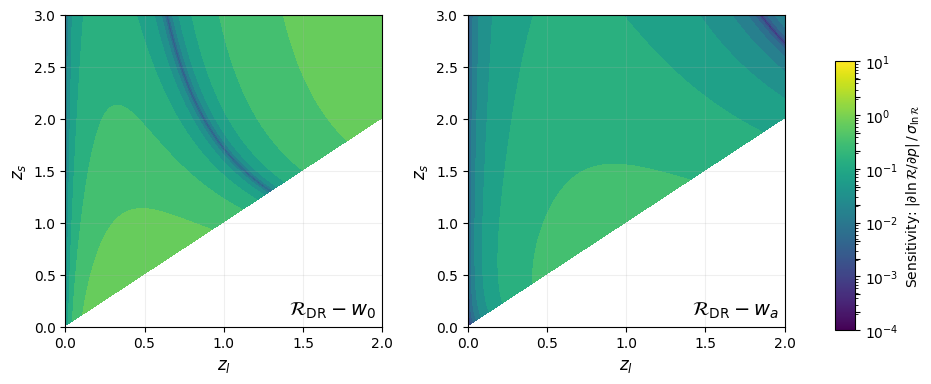

In [74]:
plot_sensitivity_contours_1x2(
    cosmo_cpl,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    # zs2_fixed=2., zs1_step=0.01,
    sigma_frac=0.1,
    outputname="contours_R_w0_wa.png"
)

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext

def plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=None,                 # expects an object with columns/keys 'zl' and 'zs'
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    # sensitivity
    sigma_frac=0.1,
    # styling
    cmap="viridis",
    scatter_color="#6a3d9a",         # purple-ish (works well with viridis)
    scatter_alpha=0.6,
    scatter_size=8,
    # figure
    figsize=(10, 4.2),
    outputname="contours_R_w0_wa_scatter.png"
):
    """
    Two subplots for R = Ds/Dls sensitivities (parameters w0 and wa),
    overlaid with (zl, zs) scatter points from LSSTa_lens on both panels.
    One shared colorbar (log, 16 levels from 1e-4 to 1e1).
    Requires dlnR_dp in scope.
    """

    # ---- ensure CPL keys (no 'w') ----
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params    = ["w0", "wa"]
    param_tex = [r"$\mathcal{R}_{\rm DR}-w_0$", r"$\mathcal{R}_{\rm DR}-w_a$"]

    # ---- grids ----
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    # ---- sensitivity helper for R ----
    def _grid_S_R(param):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # over z_s
            for j in range(ZL.shape[1]):  # over z_l
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = dlnR_dp(zl, zs, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # ---- shared color scale (16 levels, 1e-4 to 1e1) ----
    vmin, vmax = 1e-2, 1e1
    levels = np.logspace(-4, 1, 12)
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # ---- figure (leave room on right for shared colorbar) ----
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)
    axes = np.atleast_1d(axes)
    fig.subplots_adjust(right=0.86)  # free right margin for colorbar

    # in-panel parameter label style
    txt_kw = dict(ha="right", va="bottom", fontsize=14)

    # -------- draw the two panels --------
    for ax, p, ptex in zip(axes, params, param_tex):
        S = _grid_S_R(p)
        ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap,alpha=0.75,zorder=2)
        # scatter overlay (if provided)
        if LSSTa_lens is not None:
            # support dict-like or pandas DataFrame
            zl_s = np.asarray(LSSTa_lens['zl'], dtype=float)
            zs_s = np.asarray(LSSTa_lens['zs'], dtype=float)
            m = (
                np.isfinite(zl_s) & np.isfinite(zs_s) &
                (zl_s >= zl_min) & (zl_s <= zl_max) &
                (zs_s >= zs_min) & (zs_s <= zs_max) &
                (zs_s >  zl_s)
            )
            if np.any(m):
                ax.scatter(
                    zl_s[m], zs_s[m],
                    s=scatter_size, c=scatter_color, alpha=scatter_alpha,
                    edgecolors='none', rasterized=True, label="LSSTa lenses"
                )

        ax.set_ylabel(r"$z_s$", fontsize=12)
        ax.set_xlabel(r"$z_l$", fontsize=12)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # ---- shared colorbar on the right ----
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.64])  # [left, bottom, width, height]
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext(),alpha=0.75
    )
    cb.set_label(r"Sensitivity: $|\partial \ln \mathcal{R}/\partial p|\,/\,\sigma_{\ln \mathcal{R}}$")

    plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1850148/2014365859.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])


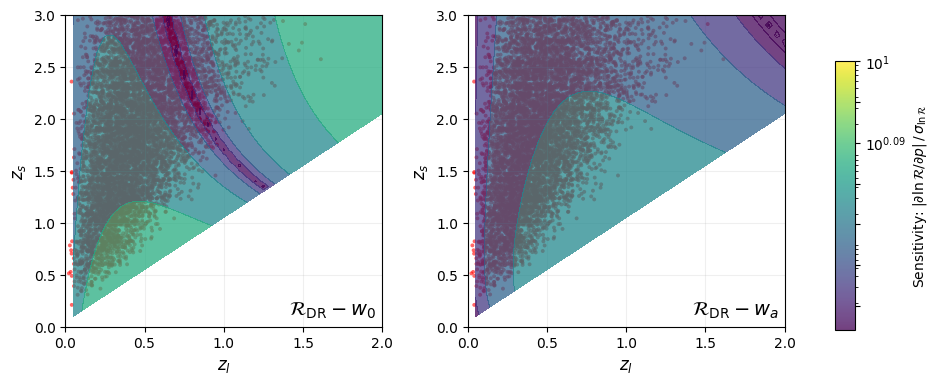

In [104]:
"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits"

from astropy.table import Table

LSSTa_lens = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits")

# Example:
cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# LSSTa_lens should be a DataFrame or dict-like with columns 'zl' and 'zs'
# e.g., LSSTa_lens = {"zl": zl_array, "zs": zs_array}

plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=LSSTa_lens,
    zl_min=0.0, zl_max=2.0, zl_step=0.05,
    zs_min=0.0, zs_max=3.0, zs_step=0.05,
    sigma_frac=0.1,
    scatter_color="red",  # purple
    outputname="contours_R_w0_wa+scatter.png"
)


In [166]:
def plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=None,                 # expects an object with columns/keys 'zl' and 'zs'
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    # sensitivity
    sigma_frac=0.1,
    # styling
    cmap="viridis",
    scatter_color="#6a3d9a",        
    scatter_alpha=0.2,
    scatter_size=6,
    # figure
    figsize=(10, 4.2),
    outputname="contours_R_w0_wa_scatter.png"
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from matplotlib.ticker import LogFormatterMathtext

    # ---- ensure CPL keys (no 'w') ----
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params    = ["w0", "wa"]
    param_tex = [r"$\mathcal{D}-w_0$", r"$\mathcal{D}-w_a$"]

    # ---- grids ----
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    # ---- sensitivity helper for R ----
    def _grid_S_R(param):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # over z_s
            for j in range(ZL.shape[1]):  # over z_l
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = dlnR_dp(zl, zs, cosmo, param)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # ---- shared color scale (16 levels, 1e-4 to 1e1) ----
    vmin, vmax = 1e-4, 10**0.2
    levels = np.logspace(-4, 0.2, 12)
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # ---- figure (leave room on right for shared colorbar) ----
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)
    axes = np.atleast_1d(axes)
    fig.subplots_adjust(right=0.86)  # free right margin for colorbar

    # in-panel parameter label style
    txt_kw = dict(ha="right", va="bottom", fontsize=14)

    # -------- draw the two panels --------
    for ax, p, ptex in zip(axes, params, param_tex):
        S = _grid_S_R(p)
        ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap, alpha=0.75, zorder=2)
        ax.contour(zl_grid, zs_grid, S, levels=levels, colors="k", linewidths=0.6, alpha=0.75, norm=norm, zorder=4)

        # scatter overlay (if provided)
        if LSSTa_lens is not None:
            # support dict-like or pandas DataFrame
            zl_s = np.asarray(LSSTa_lens['zl'], dtype=float)
            zs_s = np.asarray(LSSTa_lens['zs'], dtype=float)
            m = (
                np.isfinite(zl_s) & np.isfinite(zs_s) &
                (zl_s >= zl_min) & (zl_s <= zl_max) &
                (zs_s >= zs_min) & (zs_s <= zs_max) &
                (zs_s >  zl_s)
            )
            if np.any(m):
                ax.scatter(
                    zl_s[m], zs_s[m],
                    s=scatter_size, marker='o',
                    facecolors='none', edgecolors=scatter_color,
                    linewidths=0.8, alpha=scatter_alpha,
                    rasterized=True, zorder=3, label="LSSTa lenses"
                )

        ax.set_ylabel(r"$z_s$", fontsize=12)
        ax.set_xlabel(r"$z_l$", fontsize=12)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # ---- shared colorbar on the right ----
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.64])  # [left, bottom, width, height]
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    # cb.set_label(r"Sensitivity: $|\partial \ln \mathcal{R}/\partial p|\,/\,\sigma_{\ln \mathcal{R}}$")

    plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1850148/2455807542.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])


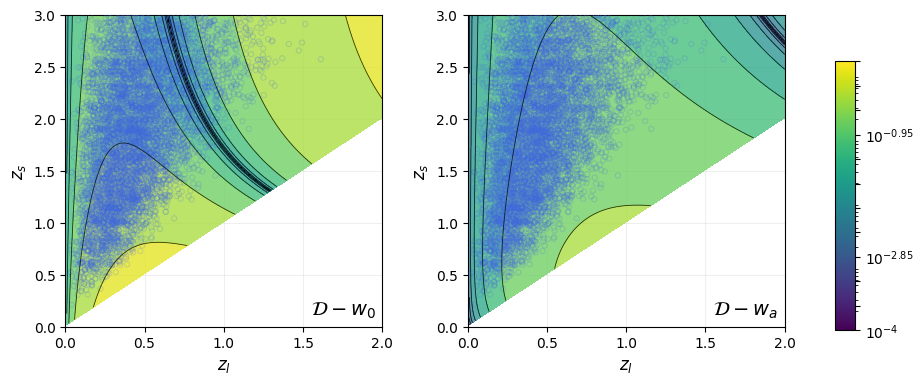

In [167]:
# "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits"

from astropy.table import Table

LSSTa_lens = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits")

# Example:
cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# LSSTa_lens should be a DataFrame or dict-like with columns 'zl' and 'zs'
# e.g., LSSTa_lens = {"zl": zl_array, "zs": zs_array}

plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=LSSTa_lens,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    sigma_frac=0.1,
    scatter_alpha=0.2,
    scatter_size=14,
    scatter_color="royalblue",  # purple
    outputname="contours_R_w0_wa+scatter.png"
)


/tmp/ipykernel_1850148/3448528156.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])


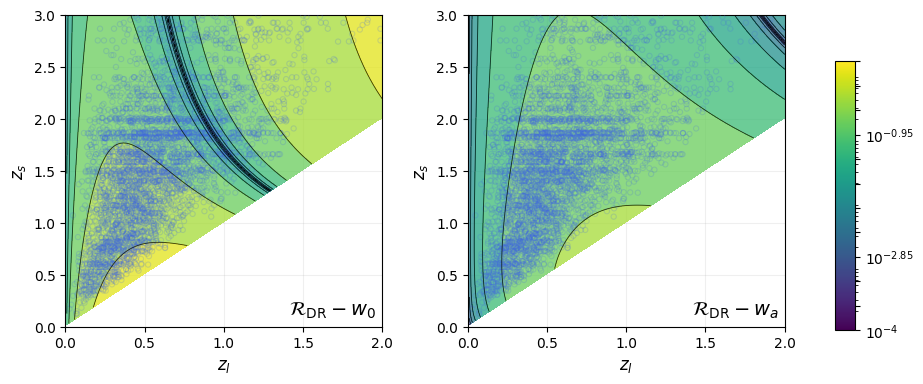

In [164]:
# "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits"

from astropy.table import Table

LSSTa_lens = Table.read(r"/home/astrodust/SG/CSST/SNR100_stacked_data.fits")

# Example:
cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# LSSTa_lens should be a DataFrame or dict-like with columns 'zl' and 'zs'
# e.g., LSSTa_lens = {"zl": zl_array, "zs": zs_array}

plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=LSSTa_lens,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    sigma_frac=0.1,
    scatter_alpha=0.2,
    scatter_size=14,
    scatter_color="royalblue",  # purple
    outputname="contours_R_w0_wa+scatter_CSST_SNR100.png"
)


/tmp/ipykernel_1850148/3448528156.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.86, 0.98])


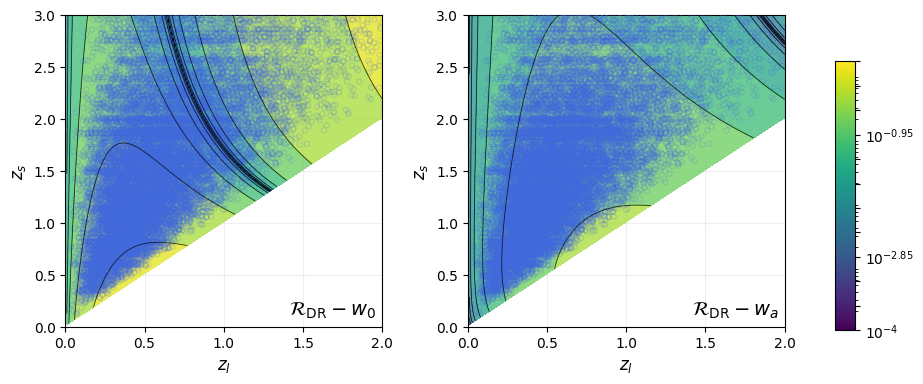

In [165]:
# "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits"

from astropy.table import Table

LSSTa_lens = Table.read(r"/home/astrodust/SG/CSST/SNR50_stacked_data.fits")

# Example:
cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# LSSTa_lens should be a DataFrame or dict-like with columns 'zl' and 'zs'
# e.g., LSSTa_lens = {"zl": zl_array, "zs": zs_array}

plot_sensitivity_R_w0_wa_with_scatter(
    cosmo_cpl,
    LSSTa_lens=LSSTa_lens,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    sigma_frac=0.1,
    scatter_alpha=0.2,
    scatter_size=14,
    scatter_color="royalblue",  # purple
    outputname="contours_R_w0_wa+scatter_CSST_SNR50.png"
)


In [158]:
# ---- 辅助：把 dict → CosmoParams ----
def _dict_to_cp(cosmo: dict) -> CosmoParams:
    return CosmoParams(
        H0   = float(cosmo.get("H0", 70.0)),
        Om0  = float(cosmo.get("omega_m", cosmo.get("Om0", 0.3))),
        Ok0  = float(cosmo.get("omega_k", cosmo.get("Ok0", 0.0))),
        Or0  = float(cosmo.get("omega_r", cosmo.get("Or0", 0.0))),
        w    = cosmo.get("w", None),
        w0   = float(cosmo.get("w0", -1.0)),
        wa   = float(cosmo.get("wa", 0.0)),
    )

# ====== FIXED: D_l 标量器 ======
def Dl_scalar(zl: float, cosmo: dict) -> float:
    """
    Angular-diameter distance from observer to lens, D_l = D_A(0 -> z_l).
    这里用你上面定义的 Dl(zl, cp)（注意：是你的包装函数，不是字典展开）。
    """
    zl = float(zl)
    if zl <= 0:
        return np.nan
    cp = _dict_to_cp(cosmo)
    return Dl(zl, cp)

def dlnDl_dp(zl: float, cosmo: dict, p: str,
             eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    数值求导：∂ ln D_l / ∂ p（中心差分）
    与 D_dt / R 的数值策略保持一致；D_l 仅依赖 z_l，与 z_s 无关。
    """
    base = Dl_scalar(zl, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    # 步长选择：对可能跨零或无量纲小值的参数用绝对步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    c_m = cosmo.copy(); c_m[p] = p_minus
    c_p = cosmo.copy(); c_p[p] = p_plus
    Dm = Dl_scalar(zl, c_m)
    Dp = Dl_scalar(zl, c_p)
    if (Dm <= 0) or (Dp <= 0) or (not np.isfinite(Dm)) or (not np.isfinite(Dp)):
        return np.nan
    return float((np.log(Dp) - np.log(Dm)) / (p_plus - p_minus))



# ====== NEW: 1×4 一维敏感度（仅 D_l vs z_l） ======
def plot_sensitivity_Dl_1x4(
    cosmo_cpl: Dict,
    *,
    zl_min=0.01, zl_max=2.0, zl_step=0.01,
    sigma_frac=0.1,
    params=("omega_m", "omega_k", "w0", "wa"),
    param_tex=(r"$D_l-\Omega_m$", r"$D_l-\Omega_k$", r"$D_l-w_0$", r"$D_l-w_a$"),
    figsize=(14, 3.6),
    outputname="sensitivity_Dl_1x4.png"
):
    """
    只画 D_l 的敏感度：S_p(z_l) = |∂ ln D_l / ∂ p| / σ_frac
    输出为一行四列，每列对应一个参数（默认：Ω_m, Ω_k, w_0, w_a）。
    注意：D_l 与 H0 的对数敏感度恒为 -1（若要画 H0，可自行添加）。
    """
    # 统一 CPL 参数键
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for j, (p, ptex) in enumerate(zip(params, param_tex)):
        ax = axes[j]
        S = np.empty_like(zl_grid, dtype=float); S[:] = np.nan
        for i, zl in enumerate(zl_grid):
            d = dlnDl_dp(float(zl), cosmo, p)
            S[i] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan

        # 掩码无效点后作图
        m = np.isfinite(S)
        ax.plot(zl_grid[m], S[m], lw=1.8)
        ax.grid(alpha=0.25)
        ax.set_xlabel(r"$z_l$", fontsize=13)
        if j == 0:
            ax.set_ylabel(r"$|\partial \ln D_l / \partial p|\,/\,\sigma_{\ln D_l}$", fontsize=13)
        ax.set_title(ptex, fontsize=15, pad=6)
        # y 轴对数可选：若动态范围很大，可打开下面两行
        # ax.set_yscale("log")
        # ax.set_ylim(1e-4, 1e2)

    plt.tight_layout()
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


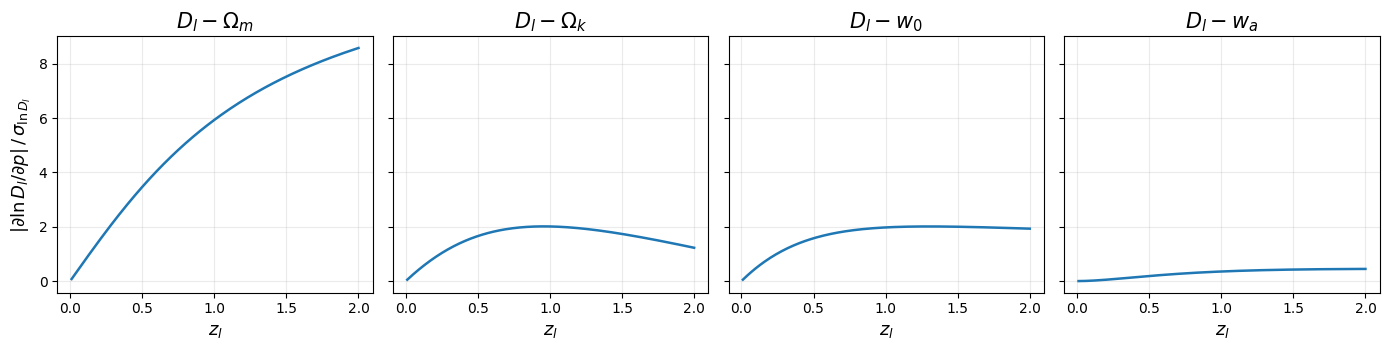

In [159]:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
plot_sensitivity_Dl_1x4(
    cosmo_cpl,
    zl_min=0.01, zl_max=2.0, zl_step=0.01,
    sigma_frac=0.1,
    outputname="Dl_sensitivity_1x4.png"
)
